<a href="https://colab.research.google.com/github/Pumlisa97/mit805-airline-delays-pyspark/blob/main/notebooks/02_part1_pyspark_preparation_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: PySpark Data Preparation and Exploratory Data Analysis

## MIT 805 Big Data Semester Project

**Dataset:** U.S. Department of Transportation Bureau of Transportation Statistics
(BTS) Reporting Carrier On-Time Performance (1987–present)

**Working dataset:** January 2020–December 2024, 60 monthly CSV files  
**Raw public dataset:** January 2015–December 2024, 120 monthly CSV files  
**Research question:** How do departure delays, arrival delays, and cancellations
vary by airline, origin airport, month, and scheduled departure period, and which
operational delay categories account for the greatest disruption?

This notebook prepares the PySpark processing dataset and performs initial data
quality assessment and exploratory data analysis. Large-scale transformations and
aggregations are performed in PySpark. Pandas is used only for small result tables
or visualisations after aggregation.

In [1]:
!pip -q install pyspark==3.5.1 pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/MIT805_Airline_Delays/data")
WORKING_DIR = DATA_ROOT / "working"
PROCESSED_DIR = DATA_ROOT / "processed"
TEMP_DIR = DATA_ROOT / "temp"

print(f"Working directory exists: {WORKING_DIR.exists()}")
print(f"Processed directory exists: {PROCESSED_DIR.exists()}")
print(f"Working CSV files: {len(list(WORKING_DIR.glob('*.csv')))}")

Mounted at /content/drive
Working directory exists: True
Processed directory exists: True
Working CSV files: 60


In [3]:
import pyspark

print(f"PySpark version: {pyspark.__version__}")

PySpark version: 3.5.1


In [45]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MIT805_Airline_Delays_Part1")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") # Changed to false
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Application name: {spark.sparkContext.appName}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")

Spark version: 3.5.1
Application name: MIT805_Airline_Delays_Part1
Default parallelism: 2


In [5]:
from pathlib import Path

single_files = sorted(WORKING_DIR.glob("*2020_1.csv"))

if not single_files:
    raise FileNotFoundError(
        "Could not find the January 2020 CSV. "
        "Check WORKING_DIR and list its contents."
    )

single_file = single_files[0]

print(f"Testing file: {single_file.name}")

test_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(str(single_file))
)

print(f"Columns found: {len(test_df.columns)}")
print(f"Last five columns: {test_df.columns[-5:]}")

test_df.select(
    "Year",
    "Month",
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "DepDelay",
    "ArrDelay",
    "Cancelled"
).show(5, truncate=False)

Testing file: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2020_1.csv
Columns found: 110
Last five columns: ['Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum', '_c109']
+----+-----+----------+-----------------+------+----+--------+--------+---------+
|Year|Month|FlightDate|Reporting_Airline|Origin|Dest|DepDelay|ArrDelay|Cancelled|
+----+-----+----------+-----------------+------+----+--------+--------+---------+
|2020|1    |2020-01-17|B6               |PBI   |BDL |-14.00  |-11.00  |0.00     |
|2020|1    |2020-01-18|B6               |PBI   |BDL |-14.00  |-9.00   |0.00     |
|2020|1    |2020-01-19|B6               |PBI   |BDL |7.00    |-6.00   |0.00     |
|2020|1    |2020-01-20|B6               |PBI   |BDL |-7.00   |4.00    |0.00     |
|2020|1    |2020-01-21|B6               |PBI   |BDL |12.00   |6.00    |0.00     |
+----+-----+----------+-----------------+------+----+--------+--------+---------+
only showing top 5 rows



In [6]:
from pyspark.sql import functions as F

working_pattern = str(WORKING_DIR / "*.csv")

raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(working_pattern)
    .withColumn("source_file", F.input_file_name())
)

print(f"Columns read: {len(raw_df.columns)}")
print(f"Input partitions: {raw_df.rdd.getNumPartitions()}")

Columns read: 111
Input partitions: 112


In [7]:
from pyspark.sql.types import (
    IntegerType,
    DoubleType,
    DateType,
)

core_string_columns = [
    "Reporting_Airline",
    "IATA_CODE_Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "OriginCityName",
    "OriginState",
    "OriginStateName",
    "Dest",
    "DestCityName",
    "DestState",
    "DestStateName",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CancellationCode",
]

integer_columns = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "DOT_ID_Reporting_Airline",
    "CRSDepTime",
    "DepTime",
    "DepDel15",
    "CRSArrTime",
    "ArrTime",
    "ArrDel15",
    "Cancelled",
    "Diverted",
    "DistanceGroup",
]

double_columns = [
    "DepDelay",
    "DepDelayMinutes",
    "ArrDelay",
    "ArrDelayMinutes",
    "CRSElapsedTime",
    "ActualElapsedTime",
    "AirTime",
    "Distance",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

selected_df = raw_df.select(
    *[F.col(column).cast("string").alias(column) for column in core_string_columns],
    *[F.col(column).cast("int").alias(column) for column in integer_columns],
    *[F.to_date(F.col("FlightDate"), "yyyy-MM-dd").alias("FlightDate")],
    *[F.col(column).cast("double").alias(column) for column in double_columns],
    F.col("source_file")
)

clean_df = (
    selected_df
    .filter(F.col("Year").between(2020, 2024))
    .filter(F.col("Month").between(1, 12))
    .filter(F.col("FlightDate").isNotNull())
    .withColumn("ScheduledDepHour", F.floor(F.col("CRSDepTime") / 100).cast("int"))
    .withColumn("FlightMonth", F.trunc(F.col("FlightDate"), "month"))
)

print(f"Core columns retained: {len(selected_df.columns) - 1}")
print(f"Columns after derived fields: {len(clean_df.columns)}")

clean_df.printSchema()

Core columns retained: 43
Columns after derived fields: 46
root
 |-- Reporting_Airline: string (nullable = true)
 |-- IATA_CODE_Reporting_Airline: string (nullable = true)
 |-- Flight_Number_Reporting_Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginCityName: string (nullable = true)
 |-- OriginState: string (nullable = true)
 |-- OriginStateName: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DestCityName: string (nullable = true)
 |-- DestState: string (nullable = true)
 |-- DestStateName: string (nullable = true)
 |-- DepTimeBlk: string (nullable = true)
 |-- ArrTimeBlk: string (nullable = true)
 |-- CancellationCode: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- DOT_ID_Reporting_Airline: integer (nullable = true)
 |-- CRSDepTime: integer (nullable =

In [10]:
import shutil

PROCESSING_PATH = PROCESSED_DIR / "airline_core_2020_2024"

if PROCESSING_PATH.exists():
    shutil.rmtree(PROCESSING_PATH)
    print("Removed previous processing output.")

(
    clean_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .partitionBy("Year", "Month")
    .parquet(str(PROCESSING_PATH))
)

print(f"Processing dataset written to: {PROCESSING_PATH}")

Processing dataset written to: /content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024


In [11]:
def folder_size_bytes(folder: Path) -> int:
    return sum(
        path.stat().st_size
        for path in folder.rglob("*")
        if path.is_file()
    )

processing_bytes = folder_size_bytes(PROCESSING_PATH)

print(f"Processing dataset size: {processing_bytes / (1024 ** 3):.3f} GiB")
print(f"Processing dataset size: {processing_bytes / 1_000_000_000:.3f} GB")

parquet_files = list(PROCESSING_PATH.rglob("*.parquet"))
print(f"Parquet data files: {len(parquet_files)}")

partition_dirs = [
    path for path in PROCESSING_PATH.rglob("Month=*")
    if path.is_dir()
]
print(f"Year-month partitions: {len(partition_dirs)}")

Processing dataset size: 0.631 GiB
Processing dataset size: 0.677 GB
Parquet data files: 60
Year-month partitions: 60


In [12]:
FULL_PROCESSING_PATH = PROCESSED_DIR / "airline_full_2020_2024_uncompressed"

if FULL_PROCESSING_PATH.exists():
    shutil.rmtree(FULL_PROCESSING_PATH)
    print("Removed previous full-schema processing output.")

full_processing_df = (
    raw_df
    .filter(F.col("Year").cast("int").between(2020, 2024))
    .filter(F.col("Month").cast("int").between(1, 12))
    .drop("_c109")
    .withColumn("Year", F.col("Year").cast("int"))
    .withColumn("Month", F.col("Month").cast("int"))
    .withColumn("FlightDate", F.to_date(F.col("FlightDate"), "yyyy-MM-dd"))
    .filter(F.col("FlightDate").isNotNull())
)

(
    full_processing_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .option("compression", "uncompressed")
    .partitionBy("Year", "Month")
    .parquet(str(FULL_PROCESSING_PATH))
)

print(f"Full processing dataset written to: {FULL_PROCESSING_PATH}")

Full processing dataset written to: /content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_full_2020_2024_uncompressed


In [13]:
full_processing_bytes = folder_size_bytes(FULL_PROCESSING_PATH)

print(f"Full processing dataset size: {full_processing_bytes / (1024 ** 3):.3f} GiB")
print(f"Full processing dataset size: {full_processing_bytes / 1_000_000_000:.3f} GB")

full_parquet_files = list(FULL_PROCESSING_PATH.rglob("*.parquet"))
print(f"Full Parquet data files: {len(full_parquet_files)}")

Full processing dataset size: 1.125 GiB
Full processing dataset size: 1.208 GB
Full Parquet data files: 60


In [14]:
CSV_PROCESSING_PATH = PROCESSED_DIR / "airline_full_2020_2024_csv"

if CSV_PROCESSING_PATH.exists():
    shutil.rmtree(CSV_PROCESSING_PATH)
    print("Removed previous CSV processing output.")

(
    full_processing_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .option("header", True)
    .option("compression", "none")
    .partitionBy("Year", "Month")
    .csv(str(CSV_PROCESSING_PATH))
)

print(f"CSV processing dataset written to: {CSV_PROCESSING_PATH}")

CSV processing dataset written to: /content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_full_2020_2024_csv


In [15]:
csv_processing_bytes = folder_size_bytes(CSV_PROCESSING_PATH)

print(f"CSV processing dataset size: {csv_processing_bytes / (1024 ** 3):.3f} GiB")
print(f"CSV processing dataset size: {csv_processing_bytes / 1_000_000_000:.3f} GB")

csv_part_files = list(CSV_PROCESSING_PATH.rglob("*.csv"))
print(f"CSV processing data files: {len(csv_part_files)}")

csv_partition_dirs = [
    path for path in CSV_PROCESSING_PATH.rglob("Month=*")
    if path.is_dir()
]
print(f"Year-month partitions: {len(csv_partition_dirs)}")

CSV processing dataset size: 14.586 GiB
CSV processing dataset size: 15.662 GB
CSV processing data files: 60
Year-month partitions: 60


## Loading the PySpark analytical dataset

The full 2020–2024 processing dataset was created as a PySpark-generated,
uncompressed, partitioned CSV collection to retain an auditable processing
layer above the required 3 GB threshold.

For efficient EDA, this notebook reads a separate PySpark-generated analytical
Parquet layer containing 43 relevant variables plus data-lineage and derived
time fields. The analysis remains distributed in PySpark; Pandas will be used
only after aggregating results into small tables for visualisation.

In [5]:
from pyspark.sql import functions as F

ANALYTICAL_PATH = PROCESSED_DIR / "airline_core_2020_2024"

flights = spark.read.parquet(str(ANALYTICAL_PATH))

print(f"Columns: {len(flights.columns)}")
print(f"Spark partitions: {flights.rdd.getNumPartitions()}")

flights.printSchema()

Columns: 46
Spark partitions: 7
root
 |-- Reporting_Airline: string (nullable = true)
 |-- IATA_CODE_Reporting_Airline: string (nullable = true)
 |-- Flight_Number_Reporting_Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginCityName: string (nullable = true)
 |-- OriginState: string (nullable = true)
 |-- OriginStateName: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DestCityName: string (nullable = true)
 |-- DestState: string (nullable = true)
 |-- DestStateName: string (nullable = true)
 |-- DepTimeBlk: string (nullable = true)
 |-- ArrTimeBlk: string (nullable = true)
 |-- CancellationCode: string (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- DOT_ID_Reporting_Airline: integer (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepTime: integer (nullable = true)
 |-- DepDel15: integer (nullable = true)
 |-- CRSArrTim

In [6]:
profile = (
    flights.agg(
        F.count("*").alias("records"),
        F.countDistinct("Reporting_Airline").alias("airlines"),
        F.countDistinct("Origin").alias("origin_airports"),
        F.countDistinct("Dest").alias("destination_airports"),
        F.min("FlightDate").alias("first_flight_date"),
        F.max("FlightDate").alias("last_flight_date"),
        F.min("Distance").alias("minimum_distance_miles"),
        F.max("Distance").alias("maximum_distance_miles"),
    )
)

profile.show(truncate=False)

+--------+--------+---------------+--------------------+-----------------+----------------+----------------------+----------------------+
|records |airlines|origin_airports|destination_airports|first_flight_date|last_flight_date|minimum_distance_miles|maximum_distance_miles|
+--------+--------+---------------+--------------------+-----------------+----------------+----------------------+----------------------+
|30241436|18      |380            |381                 |2020-01-01       |2024-12-31      |11.0                  |5812.0                |
+--------+--------+---------------+--------------------+-----------------+----------------+----------------------+----------------------+



## Missing-data assessment

Missingness is assessed in PySpark over the full 30.2-million-record analytical
dataset. Missing values are interpreted in operational context: for example,
actual timing and delay-cause fields may be null for cancelled or diverted
flights, so null values are not automatically treated as data errors.

In [7]:
from pyspark.sql import functions as F

NULL_CHECK_COLUMNS = [
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepDelay",
    "ArrDelay",
    "Cancelled",
    "Diverted",
    "Distance",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
    "CancellationCode",
]

null_summary = flights.agg(
    *[
        F.sum(F.col(column).isNull().cast("long")).alias(column)
        for column in NULL_CHECK_COLUMNS
    ]
)

null_summary.show(truncate=False)

+----------+-----------------+------+----+----------+--------+--------+---------+--------+--------+------------+------------+--------+-------------+-----------------+----------------+
|FlightDate|Reporting_Airline|Origin|Dest|CRSDepTime|DepDelay|ArrDelay|Cancelled|Diverted|Distance|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|CancellationCode|
+----------+-----------------+------+----+----------+--------+--------+---------+--------+--------+------------+------------+--------+-------------+-----------------+----------------+
|0         |0                |0     |0   |0         |715802  |798196  |0        |0       |0       |24795148    |24795148    |24795148|24795148     |24795148         |29511992        |
+----------+-----------------+------+----+----------+--------+--------+---------+--------+--------+------------+------------+--------+-------------+-----------------+----------------+



In [8]:
record_count = profile.first()["records"]

null_counts = null_summary.first().asDict()

for column in NULL_CHECK_COLUMNS:
    null_count = null_counts[column]
    null_percent = (null_count / record_count) * 100
    print(f"{column:22} | {null_count:>10,} nulls | {null_percent:6.2f}%")

FlightDate             |          0 nulls |   0.00%
Reporting_Airline      |          0 nulls |   0.00%
Origin                 |          0 nulls |   0.00%
Dest                   |          0 nulls |   0.00%
CRSDepTime             |          0 nulls |   0.00%
DepDelay               |    715,802 nulls |   2.37%
ArrDelay               |    798,196 nulls |   2.64%
Cancelled              |          0 nulls |   0.00%
Diverted               |          0 nulls |   0.00%
Distance               |          0 nulls |   0.00%
CarrierDelay           | 24,795,148 nulls |  81.99%
WeatherDelay           | 24,795,148 nulls |  81.99%
NASDelay               | 24,795,148 nulls |  81.99%
SecurityDelay          | 24,795,148 nulls |  81.99%
LateAircraftDelay      | 24,795,148 nulls |  81.99%
CancellationCode       | 29,511,992 nulls |  97.59%


### Operational interpretation of missing values

The high missingness in delay-cause and cancellation-code variables is expected to be
conditional on flight status. The following aggregation verifies whether missing
actual-delay fields correspond primarily to cancelled/diverted flights and whether
cancellation codes occur only for cancelled operations.

In [9]:
status_missingness = (
    flights
    .groupBy("Cancelled", "Diverted")
    .agg(
        F.count("*").alias("flights"),
        F.sum(F.col("DepDelay").isNull().cast("long")).alias("null_departure_delay"),
        F.sum(F.col("ArrDelay").isNull().cast("long")).alias("null_arrival_delay"),
        F.sum(F.col("CancellationCode").isNull().cast("long")).alias("null_cancellation_code"),
        F.sum(F.col("CancellationCode").isNotNull().cast("long")).alias("present_cancellation_code"),
    )
    .orderBy("Cancelled", "Diverted")
)

status_missingness.show(truncate=False)

+---------+--------+--------+--------------------+------------------+----------------------+-------------------------+
|Cancelled|Diverted|flights |null_departure_delay|null_arrival_delay|null_cancellation_code|present_cancellation_code|
+---------+--------+--------+--------------------+------------------+----------------------+-------------------------+
|0        |0       |29443244|0                   |4                 |29443244              |0                        |
|0        |1       |68748   |0                   |68748             |68748                 |0                        |
|1        |0       |729444  |715802              |729444            |0                     |729444                   |
+---------+--------+--------+--------------------+------------------+----------------------+-------------------------+



In [10]:
disruption_summary = (
    flights.agg(
        F.count("*").alias("total_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
    )
)

disruption_summary.show(truncate=False)

+-------------+-----------------+----------------+-------------------+--------------------+
|total_flights|cancelled_flights|diverted_flights|cancellation_rate  |diversion_rate      |
+-------------+-----------------+----------------+-------------------+--------------------+
|30241436     |729444           |68748           |0.02412067998358279|0.002273304746507408|
+-------------+-----------------+----------------+-------------------+--------------------+



## Data-quality rules for analysis

- Scheduled-flight volume and cancellation metrics retain all records because flight
  date, airline, origin, destination, scheduled departure time, distance, and
  cancellation/diversion flags are complete.
- Arrival-delay metrics use standard completed flights only:
  `Cancelled = 0`, `Diverted = 0`, and non-null `ArrDelay`.
- Departure-delay metrics exclude records with null `DepDelay`; these occur
  predominantly among cancelled flights.
- Delay-cause fields are not imputed with zero because they are conditionally
  reported and are null for most records. Cause-specific analyses use only
  qualifying records where the fields are present.
- `CancellationCode` is analysed only among cancelled flights, where it is
  complete.

In [11]:
validity_checks = (
    flights.agg(
        F.sum((F.col("Distance") <= 0).cast("long")).alias("non_positive_distance"),
        F.sum((F.col("Distance") > 6000).cast("long")).alias("distance_over_6000_miles"),
        F.sum((F.col("ActualElapsedTime") <= 0).cast("long")).alias("non_positive_actual_elapsed_time"),
        F.sum((F.col("AirTime") <= 0).cast("long")).alias("non_positive_air_time"),
        F.sum((F.col("DepDelay") < -60).cast("long")).alias("departure_more_than_60_minutes_early"),
        F.sum((F.col("ArrDelay") < -60).cast("long")).alias("arrival_more_than_60_minutes_early"),
        F.sum((F.col("ArrDelay") > 1440).cast("long")).alias("arrival_delay_over_24_hours"),
        F.sum(
            (
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0)
                & F.col("ArrDelay").isNull()
            ).cast("long")
        ).alias("standard_operated_flights_with_null_arrival_delay"),
    )
)

validity_checks.show(truncate=False)

+---------------------+------------------------+--------------------------------+---------------------+------------------------------------+----------------------------------+---------------------------+-------------------------------------------------+
|non_positive_distance|distance_over_6000_miles|non_positive_actual_elapsed_time|non_positive_air_time|departure_more_than_60_minutes_early|arrival_more_than_60_minutes_early|arrival_delay_over_24_hours|standard_operated_flights_with_null_arrival_delay|
+---------------------+------------------------+--------------------------------+---------------------+------------------------------------+----------------------------------+---------------------------+-------------------------------------------------+
|0                    |0                       |0                               |0                    |84                                  |5543                              |1803                       |4                                  

In [12]:
completed_flights = flights.filter(
    (F.col("Cancelled") == 0)
    & (F.col("Diverted") == 0)
    & F.col("ArrDelay").isNotNull()
)

delay_statistics = (
    completed_flights
    .agg(
        F.count("*").alias("standard_completed_flights"),
        F.avg("DepDelay").alias("mean_departure_delay_minutes"),
        F.expr("percentile_approx(DepDelay, 0.5, 10000)").alias("median_departure_delay_minutes"),
        F.avg("ArrDelay").alias("mean_arrival_delay_minutes"),
        F.expr("percentile_approx(ArrDelay, 0.5, 10000)").alias("median_arrival_delay_minutes"),
        F.avg("Distance").alias("mean_distance_miles"),
        F.expr("percentile_approx(Distance, 0.5, 10000)").alias("median_distance_miles"),
        F.min("ArrDelay").alias("minimum_arrival_delay_minutes"),
        F.max("ArrDelay").alias("maximum_arrival_delay_minutes"),
    )
)

delay_statistics.show(truncate=False)

+--------------------------+----------------------------+------------------------------+--------------------------+----------------------------+-------------------+---------------------+-----------------------------+-----------------------------+
|standard_completed_flights|mean_departure_delay_minutes|median_departure_delay_minutes|mean_arrival_delay_minutes|median_arrival_delay_minutes|mean_distance_miles|median_distance_miles|minimum_arrival_delay_minutes|maximum_arrival_delay_minutes|
+--------------------------+----------------------------+------------------------------+--------------------------+----------------------------+-------------------+---------------------+-----------------------------+-----------------------------+
|29443240                  |10.31953867848783           |-2.0                          |4.442034572282126         |-7.0                        |819.2916609381305  |671.0                |-139.0                       |4405.0                       |
+-----------

## Initial descriptive findings

Among 29,443,240 standard completed flights, the median departure delay was
−2 minutes and the median arrival delay was −7 minutes, indicating that the
typical completed flight departed and arrived slightly ahead of schedule.

However, mean departure and arrival delays were 10.32 and 4.44 minutes,
respectively. The difference between the mean and median indicates a strongly
right-skewed distribution: a relatively small number of severe disruptions
substantially increases average delay.

No non-positive distance, air-time, or actual elapsed-time values were found.
However, 1,803 flights had arrival delays exceeding 24 hours, while arrival
delays ranged from −139 to 4,405 minutes. These records will be retained for
operational disruption analysis but visualisations will use percentile-based
limits or robust statistics to avoid distortion by extreme values.

In [13]:
delay_percentiles = (
    completed_flights
    .agg(
        F.expr(
            "percentile_approx(ArrDelay, array(0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99), 10000)"
        ).alias("arrival_delay_percentiles"),
        F.expr(
            "percentile_approx(DepDelay, array(0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99), 10000)"
        ).alias("departure_delay_percentiles"),
        F.expr(
            "percentile_approx(Distance, array(0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99), 10000)"
        ).alias("distance_percentiles"),
    )
)

delay_percentiles.show(truncate=False)

+---------------------------------------------+--------------------------------------------+----------------------------------------------------+
|arrival_delay_percentiles                    |departure_delay_percentiles                 |distance_percentiles                                |
+---------------------------------------------+--------------------------------------------+----------------------------------------------------+
|[-37.0, -28.0, -16.0, -7.0, 7.0, 71.0, 192.0]|[-14.0, -10.0, -6.0, -2.0, 7.0, 72.0, 194.0]|[100.0, 175.0, 391.0, 671.0, 1055.0, 2153.0, 2607.0]|
+---------------------------------------------+--------------------------------------------+----------------------------------------------------+



In [14]:
service_summary = (
    completed_flights
    .agg(
        F.count("*").alias("completed_flights"),
        F.sum((F.col("ArrDelay") <= 0).cast("long")).alias("arrived_on_or_early"),
        F.sum((F.col("ArrDelay") > 0).cast("long")).alias("arrived_late"),
        F.sum((F.col("ArrDelay") >= 15).cast("long")).alias("arrived_15_plus_minutes_late"),
        F.sum((F.col("ArrDelay") >= 60).cast("long")).alias("arrived_60_plus_minutes_late"),
        F.avg((F.col("ArrDelay") <= 0).cast("double")).alias("on_or_early_rate"),
        F.avg((F.col("ArrDelay") >= 15).cast("double")).alias("delay_15_plus_rate"),
        F.avg((F.col("ArrDelay") >= 60).cast("double")).alias("delay_60_plus_rate"),
    )
)

service_summary.show(truncate=False)

+-----------------+-------------------+------------+----------------------------+----------------------------+-----------------+-------------------+-------------------+
|completed_flights|arrived_on_or_early|arrived_late|arrived_15_plus_minutes_late|arrived_60_plus_minutes_late|on_or_early_rate |delay_15_plus_rate |delay_60_plus_rate |
+-----------------+-------------------+------------+----------------------------+----------------------------+-----------------+-------------------+-------------------+
|29443240         |19512133           |9931107     |5446293                     |1811603                     |0.662703323411418|0.18497600807519823|0.06152865649296749|
+-----------------+-------------------+------------+----------------------------+----------------------------+-----------------+-------------------+-------------------+



## Arrival reliability and distribution

Of 29,443,240 standard completed flights, 66.27% arrived on or ahead of
schedule. Nevertheless, 18.50% arrived at least 15 minutes late and 6.15%
arrived at least 60 minutes late.

The arrival-delay distribution is strongly right-skewed. The median arrival
delay was −7 minutes, while the 95th and 99th percentiles were 71 and
192 minutes, respectively. Therefore, mean delay alone is insufficient for
operational performance assessment; median, threshold-based delay rates, and
upper-percentile measures better represent typical performance and disruption
risk.

For visualisations of delay distributions, the 1st–99th percentile range
(−37 to 192 minutes) will be used to reduce distortion from rare extreme
records. Distance is also right-skewed, with a median of 671 miles and a
95th percentile of 2,153 miles.

In [15]:
yearly_summary = (
    flights
    .groupBy("Year")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Diverted").alias("diversion_rate"),
        F.sum(
            (
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0)
                & (F.col("ArrDelay") >= 15)
            ).cast("long")
        ).alias("arrival_delay_15_plus_flights"),
        F.sum(
            (
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0)
                & F.col("ArrDelay").isNotNull()
            ).cast("long")
        ).alias("standard_completed_flights"),
        F.avg(
            F.when(
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0),
                F.col("ArrDelay")
            )
        ).alias("mean_arrival_delay_minutes"),
        F.expr(
            """
            percentile_approx(
                CASE
                    WHEN Cancelled = 0
                     AND Diverted = 0
                     AND ArrDelay IS NOT NULL
                    THEN ArrDelay
                END,
                0.5,
                10000
            )
            """
        ).alias("median_arrival_delay_minutes"),
    )
    .withColumn(
        "arrival_delay_15_plus_rate",
        F.col("arrival_delay_15_plus_flights") / F.col("standard_completed_flights")
    )
    .orderBy("Year")
)

yearly_summary.show(truncate=False)

+----+-----------------+-----------------+--------------------+----------------+---------------------+-----------------------------+--------------------------+--------------------------+----------------------------+--------------------------+
|Year|scheduled_flights|cancelled_flights|cancellation_rate   |diverted_flights|diversion_rate       |arrival_delay_15_plus_flights|standard_completed_flights|mean_arrival_delay_minutes|median_arrival_delay_minutes|arrival_delay_15_plus_rate|
+----+-----------------+-----------------+--------------------+----------------+---------------------+-----------------------------+--------------------------+--------------------------+----------------------------+--------------------------+
|2020|4688354          |281034           |0.05994299918478852 |7744            |0.0016517524060683131|431921                       |4399575                   |-4.989809924822284        |-11.0                       |0.0981733462891302        |
|2021|5416218          |8586

In [16]:
monthly_summary = (
    flights
    .groupBy("FlightMonth")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg(
            F.when(
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0),
                F.col("ArrDelay")
            )
        ).alias("mean_arrival_delay_minutes"),
        F.sum(
            (
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0)
                & (F.col("ArrDelay") >= 15)
            ).cast("long")
        ).alias("arrival_delay_15_plus_flights"),
        F.sum(
            (
                (F.col("Cancelled") == 0)
                & (F.col("Diverted") == 0)
                & F.col("ArrDelay").isNotNull()
            ).cast("long")
        ).alias("standard_completed_flights"),
    )
    .withColumn(
        "arrival_delay_15_plus_rate",
        F.col("arrival_delay_15_plus_flights") / F.col("standard_completed_flights")
    )
    .orderBy("FlightMonth")
)

monthly_summary.show(60, truncate=False)

+-----------+-----------------+---------------------+--------------------------+-----------------------------+--------------------------+--------------------------+
|FlightMonth|scheduled_flights|cancellation_rate    |mean_arrival_delay_minutes|arrival_delay_15_plus_flights|standard_completed_flights|arrival_delay_15_plus_rate|
+-----------+-----------------+---------------------+--------------------------+-----------------------------+--------------------------+--------------------------+
|2020-01-01 |607346           |0.011407006879110095 |-1.6207990414972933       |82285                        |599268                    |0.13730918387098928       |
|2020-02-01 |574268           |0.00894181810583212  |-0.19684161978326845      |84616                        |568076                    |0.14895190080200538       |
|2020-03-01 |648229           |0.169981596010052    |-6.355562835508633        |53720                        |537244                    |0.09999181005278793       |
|2020-04-0

In [17]:
monthly_summary.orderBy(
    F.desc("arrival_delay_15_plus_rate")
).show(5, truncate=False)

+-----------+-----------------+--------------------+--------------------------+-----------------------------+--------------------------+--------------------------+
|FlightMonth|scheduled_flights|cancellation_rate   |mean_arrival_delay_minutes|arrival_delay_15_plus_flights|standard_completed_flights|arrival_delay_15_plus_rate|
+-----------+-----------------+--------------------+--------------------------+-----------------------------+--------------------------+--------------------------+
|2024-07-01 |634613           |0.028949926963361922|18.092325283660564        |181865                       |613938                    |0.2962269805745857        |
|2023-07-01 |601866           |0.02426786028783816 |16.64182525493199         |167080                       |585058                    |0.28557852383866217       |
|2022-12-01 |557095           |0.054895484612139764|13.76753519987053         |142407                       |525215                    |0.2711403901259484        |
|2023-06-01 |577

In [18]:
month_coverage = (
    flights
    .groupBy("Year", "Month", "FlightMonth")
    .agg(F.count("*").alias("scheduled_flights"))
    .orderBy("Year", "Month")
)

month_coverage.show(70, truncate=False)

expected_periods = {
    (year, month)
    for year in range(2020, 2025)
    for month in range(1, 13)
}

observed_periods = {
    (row["Year"], row["Month"])
    for row in month_coverage.select("Year", "Month").collect()
}

missing_periods = sorted(expected_periods - observed_periods)

print(f"Observed year-months: {len(observed_periods)}")
print(f"Missing year-months: {missing_periods if missing_periods else 'None'}")

+----+-----+-----------+-----------------+
|Year|Month|FlightMonth|scheduled_flights|
+----+-----+-----------+-----------------+
|2020|1    |2020-01-01 |607346           |
|2020|2    |2020-02-01 |574268           |
|2020|3    |2020-03-01 |648229           |
|2020|4    |2020-04-01 |313382           |
|2020|5    |2020-05-01 |180617           |
|2020|6    |2020-06-01 |223732           |
|2020|7    |2020-07-01 |352888           |
|2020|8    |2020-08-01 |376715           |
|2020|9    |2020-09-01 |323347           |
|2020|10   |2020-10-01 |352106           |
|2020|11   |2020-11-01 |364367           |
|2020|12   |2020-12-01 |371357           |
|2021|1    |2021-01-01 |361428           |
|2021|2    |2021-02-01 |332468           |
|2021|3    |2021-03-01 |444476           |
|2021|4    |2021-04-01 |450637           |
|2021|5    |2021-05-01 |495544           |
|2021|6    |2021-06-01 |546124           |
|2021|7    |2021-07-01 |583258           |
|2021|9    |2021-09-01 |538051           |
|2021|10   

In [19]:
from collections import Counter
import re

parquet_files = list(ANALYTICAL_PATH.rglob("*.parquet"))

year_month_pattern = re.compile(r"Year=(\d{4})/Month=(\d{1,2})")
physical_partitions = set()

for file in parquet_files:
    match = year_month_pattern.search(str(file))
    if match:
        physical_partitions.add(
            (int(match.group(1)), int(match.group(2)))
        )

missing_physical = sorted(expected_periods - physical_partitions)

print(f"Parquet files: {len(parquet_files)}")
print(f"Physical year-month partitions: {len(physical_partitions)}")
print(f"Missing physical partitions: {missing_physical if missing_physical else 'None'}")

Parquet files: 58
Physical year-month partitions: 58
Missing physical partitions: [(2021, 8), (2024, 2)]


## Temporal patterns

The dataset shows substantial year-to-year and seasonal variability. Scheduled
flight volume rose from 4.69 million in 2020 to 6.56 million in 2024. Over the
same comparison, the rate of standard completed flights arriving at least
15 minutes late rose from 9.82% to 21.21%.

The highest monthly 15-minute delay rate was observed in July 2024 (29.62%),
followed by July 2023 (28.56%) and December 2022 (27.11%). These results show
that annual averages conceal substantial time-specific operational disruption.
The findings are descriptive and do not establish the causal drivers of the
observed patterns.

In [21]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/MIT805_Airline_Delays/data")

RAW_DIR = DATA_ROOT / "raw"
WORKING_DIR = DATA_ROOT / "working"
PROCESSED_DIR = DATA_ROOT / "processed"
TEMP_DIR = DATA_ROOT / "temp"

for directory in [RAW_DIR, WORKING_DIR, PROCESSED_DIR, TEMP_DIR]:
    print(f"{directory.name:10} | exists: {directory.exists()} | {directory}")

raw        | exists: True | /content/drive/MyDrive/MIT805_Airline_Delays/data/raw
working    | exists: True | /content/drive/MyDrive/MIT805_Airline_Delays/data/working
processed  | exists: True | /content/drive/MyDrive/MIT805_Airline_Delays/data/processed
temp       | exists: True | /content/drive/MyDrive/MIT805_Airline_Delays/data/temp


In [22]:
required_test_files = [
    "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2021_8.zip",
    "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_2.zip",
]

for filename in required_test_files:
    path = RAW_DIR / filename
    print(f"{filename} | exists: {path.exists()}")

On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2021_8.zip | exists: True
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_2.zip | exists: True


In [23]:
import zipfile
from pathlib import Path

missing_month_zips = [
    RAW_DIR / "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2021_8.zip",
    RAW_DIR / "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_2.zip",
]

for zip_path in missing_month_zips:
    with zipfile.ZipFile(zip_path, "r") as archive:
        csv_members = [
            member
            for member in archive.infolist()
            if member.filename.lower().endswith(".csv")
        ]

        if len(csv_members) != 1:
            raise ValueError(
                f"Expected exactly one CSV in {zip_path.name}; "
                f"found {len(csv_members)}."
            )

        member = csv_members[0]
        target_path = WORKING_DIR / Path(member.filename).name

        if target_path.exists():
            print(f"Already exists: {target_path.name}")
        else:
            print(f"Extracting: {target_path.name}")

            with archive.open(member) as source, open(target_path, "wb") as target:
                while True:
                    chunk = source.read(16 * 1024 * 1024)
                    if not chunk:
                        break
                    target.write(chunk)

Already exists: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2021_8.csv
Already exists: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_2.csv


In [24]:
import re

def extract_year_month(filename: str):
    match = re.search(r"_(\d{4})_(\d{1,2})\.(csv|zip)$", filename)
    return (int(match.group(1)), int(match.group(2))) if match else None

expected_periods = {
    (year, month)
    for year in range(2020, 2025)
    for month in range(1, 13)
}

working_csvs = sorted(WORKING_DIR.glob("*.csv"))
working_periods = set()

for path in working_csvs:
    parsed = extract_year_month(path.name)
    if parsed:
        working_periods.add(parsed)

missing_working = sorted(expected_periods - working_periods)

working_bytes = sum(path.stat().st_size for path in working_csvs)

print(f"Working CSV files: {len(working_csvs)}")
print(f"Observed working year-months: {len(working_periods)}")
print(f"Missing working periods: {missing_working if missing_working else 'None'}")
print(f"Working dataset size: {working_bytes / (1024 ** 3):.3f} GiB")
print(f"Working dataset size: {working_bytes / 1_000_000_000:.3f} GB")

Working CSV files: 60
Observed working year-months: 60
Missing working periods: None
Working dataset size: 13.159 GiB
Working dataset size: 14.130 GB


In [25]:
from pyspark.sql import functions as F
import shutil

working_pattern = str(WORKING_DIR / "*.csv")

raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(working_pattern)
    .withColumn("source_file", F.input_file_name())
)

core_string_columns = [
    "Reporting_Airline",
    "IATA_CODE_Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "OriginCityName",
    "OriginState",
    "OriginStateName",
    "Dest",
    "DestCityName",
    "DestState",
    "DestStateName",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CancellationCode",
]

integer_columns = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "DOT_ID_Reporting_Airline",
    "CRSDepTime",
    "DepTime",
    "DepDel15",
    "CRSArrTime",
    "ArrTime",
    "ArrDel15",
    "Cancelled",
    "Diverted",
    "DistanceGroup",
]

double_columns = [
    "DepDelay",
    "DepDelayMinutes",
    "ArrDelay",
    "ArrDelayMinutes",
    "CRSElapsedTime",
    "ActualElapsedTime",
    "AirTime",
    "Distance",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

selected_df = raw_df.select(
    *[F.col(column).cast("string").alias(column) for column in core_string_columns],
    *[F.col(column).cast("int").alias(column) for column in integer_columns],
    F.to_date(F.col("FlightDate"), "yyyy-MM-dd").alias("FlightDate"),
    *[F.col(column).cast("double").alias(column) for column in double_columns],
    F.col("source_file")
)

clean_df = (
    selected_df
    .filter(F.col("Year").between(2020, 2024))
    .filter(F.col("Month").between(1, 12))
    .filter(F.col("FlightDate").isNotNull())
    .withColumn("ScheduledDepHour", F.floor(F.col("CRSDepTime") / 100).cast("int"))
    .withColumn("FlightMonth", F.trunc(F.col("FlightDate"), "month"))
)

print(f"Source files matched: {len(list(WORKING_DIR.glob('*.csv')))}")
print(f"Raw columns including source_file: {len(raw_df.columns)}")
print(f"Final analytical columns: {len(clean_df.columns)}")

Source files matched: 60
Raw columns including source_file: 111
Final analytical columns: 46


In [26]:
ANALYTICAL_PATH = PROCESSED_DIR / "airline_core_2020_2024"

if ANALYTICAL_PATH.exists():
    shutil.rmtree(ANALYTICAL_PATH)
    print("Removed the incomplete analytical Parquet output.")

(
    clean_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .partitionBy("Year", "Month")
    .parquet(str(ANALYTICAL_PATH))
)

print(f"Rebuilt analytical dataset: {ANALYTICAL_PATH}")

Removed the incomplete analytical Parquet output.
Rebuilt analytical dataset: /content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024


In [27]:
reloaded_flights = spark.read.parquet(str(ANALYTICAL_PATH))

coverage = (
    reloaded_flights
    .groupBy("Year", "Month")
    .count()
    .orderBy("Year", "Month")
)

observed_periods = {
    (row["Year"], row["Month"])
    for row in coverage.select("Year", "Month").collect()
}

missing_parquet_periods = sorted(expected_periods - observed_periods)

print(f"Parquet year-month partitions: {len(observed_periods)}")
print(
    "Missing Parquet periods: "
    f"{missing_parquet_periods if missing_parquet_periods else 'None'}"
)

coverage.filter(
    ((F.col("Year") == 2021) & (F.col("Month") == 8))
    | ((F.col("Year") == 2024) & (F.col("Month") == 2))
).show()

Parquet year-month partitions: 60
Missing Parquet periods: None
+----+-----+------+
|Year|Month| count|
+----+-----+------+
|2021|    8|579179|
|2024|    2|519221|
+----+-----+------+



In [28]:
flights = spark.read.parquet(str(ANALYTICAL_PATH))

print(f"Columns: {len(flights.columns)}")
print(f"Spark partitions: {flights.rdd.getNumPartitions()}")

Columns: 46
Spark partitions: 7


In [29]:
profile = (
    flights.agg(
        F.count("*").alias("records"),
        F.countDistinct("Reporting_Airline").alias("airlines"),
        F.countDistinct("Origin").alias("origin_airports"),
        F.countDistinct("Dest").alias("destination_airports"),
        F.min("FlightDate").alias("first_flight_date"),
        F.max("FlightDate").alias("last_flight_date"),
        F.min("Distance").alias("minimum_distance_miles"),
        F.max("Distance").alias("maximum_distance_miles"),
    )
)

profile.show(truncate=False)

+--------+--------+---------------+--------------------+-----------------+----------------+----------------------+----------------------+
|records |airlines|origin_airports|destination_airports|first_flight_date|last_flight_date|minimum_distance_miles|maximum_distance_miles|
+--------+--------+---------------+--------------------+-----------------+----------------+----------------------+----------------------+
|31339836|18      |380            |381                 |2020-01-01       |2024-12-31      |11.0                  |5812.0                |
+--------+--------+---------------+--------------------+-----------------+----------------+----------------------+----------------------+



In [30]:
year_dirs = sorted(
    path for path in ANALYTICAL_PATH.glob("Year=*")
    if path.is_dir()
)

month_dirs = sorted(
    path
    for year_dir in year_dirs
    for path in year_dir.glob("Month=*")
    if path.is_dir()
)

print(f"Year partition directories: {len(year_dirs)}")
print(f"Month partition directories: {len(month_dirs)}")
print("First five:", [str(path.relative_to(ANALYTICAL_PATH)) for path in month_dirs[:5]])
print("Last five:", [str(path.relative_to(ANALYTICAL_PATH)) for path in month_dirs[-5:]])

Year partition directories: 5
Month partition directories: 60
First five: ['Year=2020/Month=1', 'Year=2020/Month=10', 'Year=2020/Month=11', 'Year=2020/Month=12', 'Year=2020/Month=2']
Last five: ['Year=2024/Month=5', 'Year=2024/Month=6', 'Year=2024/Month=7', 'Year=2024/Month=8', 'Year=2024/Month=9']


In [31]:
from pyspark.sql import functions as F

quality_summary = (
    flights.agg(
        F.count("*").alias("records"),

        F.sum(F.col("Cancelled")).alias("cancelled_flights"),
        F.sum(F.col("Diverted")).alias("diverted_flights"),
        F.sum(F.col("DepDel15")).alias("departure_delayed_15m"),
        F.sum(F.col("ArrDel15")).alias("arrival_delayed_15m"),

        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("DepDel15").alias("departure_delay_15m_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate"),

        F.sum(F.when(F.col("FlightDate").isNull(), 1).otherwise(0)).alias("null_flight_date"),
        F.sum(F.when(F.col("Reporting_Airline").isNull(), 1).otherwise(0)).alias("null_airline"),
        F.sum(F.when(F.col("Origin").isNull(), 1).otherwise(0)).alias("null_origin"),
        F.sum(F.when(F.col("Dest").isNull(), 1).otherwise(0)).alias("null_destination"),

        F.sum(F.when(F.col("Cancelled") == 0, 1).otherwise(0)).alias("operated_flights"),
        F.sum(
            F.when(
                (F.col("Cancelled") == 0) & F.col("DepDelay").isNull(),
                1
            ).otherwise(0)
        ).alias("operated_missing_departure_delay"),
        F.sum(
            F.when(
                (F.col("Cancelled") == 0) & F.col("ArrDelay").isNull(),
                1
            ).otherwise(0)
        ).alias("operated_missing_arrival_delay"),

        F.sum(F.when(F.col("Distance") <= 0, 1).otherwise(0)).alias("nonpositive_distance"),
        F.sum(
            F.when(
                (F.col("Cancelled") == 0) &
                ((F.col("CRSDepTime") < 0) | (F.col("CRSDepTime") > 2359)),
                1
            ).otherwise(0)
        ).alias("invalid_scheduled_departure_time"),
        F.sum(
            F.when(
                (F.col("Cancelled") == 0) &
                ((F.col("CRSArrTime") < 0) | (F.col("CRSArrTime") > 2359)),
                1
            ).otherwise(0)
        ).alias("invalid_scheduled_arrival_time")
    )
)

quality_summary.show(truncate=False)

+--------+-----------------+----------------+---------------------+-------------------+--------------------+---------------------+------------------------+----------------------+----------------+------------+-----------+----------------+----------------+--------------------------------+------------------------------+--------------------+--------------------------------+------------------------------+
|records |cancelled_flights|diverted_flights|departure_delayed_15m|arrival_delayed_15m|cancellation_rate   |diversion_rate       |departure_delay_15m_rate|arrival_delay_15m_rate|null_flight_date|null_airline|null_origin|null_destination|operated_flights|operated_missing_departure_delay|operated_missing_arrival_delay|nonpositive_distance|invalid_scheduled_departure_time|invalid_scheduled_arrival_time|
+--------+-----------------+----------------+---------------------+-------------------+--------------------+---------------------+------------------------+----------------------+--------------

In [32]:
operated_flights = flights.filter(F.col("Cancelled") == 0)

delay_statistics = (
    operated_flights
    .agg(
        F.count("*").alias("operated_flights"),

        F.avg("DepDelay").alias("mean_departure_delay_min"),
        F.stddev("DepDelay").alias("sd_departure_delay_min"),
        F.min("DepDelay").alias("min_departure_delay_min"),
        F.max("DepDelay").alias("max_departure_delay_min"),

        F.avg("ArrDelay").alias("mean_arrival_delay_min"),
        F.stddev("ArrDelay").alias("sd_arrival_delay_min"),
        F.min("ArrDelay").alias("min_arrival_delay_min"),
        F.max("ArrDelay").alias("max_arrival_delay_min"),

        F.avg("Distance").alias("mean_distance_miles"),
        F.min("Distance").alias("min_distance_miles"),
        F.max("Distance").alias("max_distance_miles"),

        F.avg("CRSElapsedTime").alias("mean_scheduled_elapsed_min"),
        F.avg("ActualElapsedTime").alias("mean_actual_elapsed_min")
    )
)

delay_percentiles = (
    operated_flights
    .select(
        F.expr(
            "percentile_approx(DepDelay, array(0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99), 10000)"
        ).alias("departure_delay_percentiles"),
        F.expr(
            "percentile_approx(ArrDelay, array(0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99), 10000)"
        ).alias("arrival_delay_percentiles"),
        F.expr(
            "percentile_approx(Distance, array(0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99), 10000)"
        ).alias("distance_percentiles")
    )
)

delay_statistics.show(truncate=False)
delay_percentiles.show(truncate=False)

+----------------+------------------------+----------------------+-----------------------+-----------------------+----------------------+--------------------+---------------------+---------------------+-------------------+------------------+------------------+--------------------------+-----------------------+
|operated_flights|mean_departure_delay_min|sd_departure_delay_min|min_departure_delay_min|max_departure_delay_min|mean_arrival_delay_min|sd_arrival_delay_min|min_arrival_delay_min|max_arrival_delay_min|mean_distance_miles|min_distance_miles|max_distance_miles|mean_scheduled_elapsed_min|mean_actual_elapsed_min|
+----------------+------------------------+----------------------+-----------------------+-----------------------+----------------------+--------------------+---------------------+---------------------+-------------------+------------------+------------------+--------------------------+-----------------------+
|30590198        |10.386503578695372      |51.11234493544376    

In [33]:
completed_flights = (
    flights
    .filter(F.col("Cancelled") == 0)
    .filter(F.col("Diverted") == 0)
    .filter(F.col("ArrDelay").isNotNull())
)

yearly_trends = (
    flights
    .groupBy("Year")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate"),
        F.avg("DepDel15").alias("departure_delay_15m_rate")
    )
    .join(
        completed_flights
        .groupBy("Year")
        .agg(
            F.count("*").alias("completed_nondiverted_flights"),
            F.avg("ArrDelay").alias("mean_arrival_delay_min"),
            F.expr("percentile_approx(ArrDelay, 0.50, 10000)").alias(
                "median_arrival_delay_min"
            ),
            F.expr("percentile_approx(ArrDelay, 0.90, 10000)").alias(
                "p90_arrival_delay_min"
            ),
            F.expr("percentile_approx(ArrDelay, 0.95, 10000)").alias(
                "p95_arrival_delay_min"
            )
        ),
        on="Year",
        how="left"
    )
    .orderBy("Year")
)

yearly_trends.show(truncate=False)

+----+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+---------------------+
|Year|scheduled_flights|cancelled_flights|diverted_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|departure_delay_15m_rate|completed_nondiverted_flights|mean_arrival_delay_min|median_arrival_delay_min|p90_arrival_delay_min|p95_arrival_delay_min|
+----+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+---------------------+
|2020|4688354          |281034           |7744            |0.05994299918478852 |0.0016517524060683131|0.0981733462891302    |0.09099605190480566     |4399575                      |-

In [34]:
monthly_seasonality = (
    flights
    .groupBy("Month")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate"),
        F.avg("DepDel15").alias("departure_delay_15m_rate")
    )
    .join(
        completed_flights
        .groupBy("Month")
        .agg(
            F.count("*").alias("completed_nondiverted_flights"),
            F.avg("ArrDelay").alias("mean_arrival_delay_min"),
            F.expr("percentile_approx(ArrDelay, 0.50, 10000)").alias(
                "median_arrival_delay_min"
            ),
            F.expr("percentile_approx(ArrDelay, 0.90, 10000)").alias(
                "p90_arrival_delay_min"
            )
        ),
        on="Month",
        how="left"
    )
    .orderBy("Month")
)

monthly_seasonality.show(12, truncate=False)

+-----+-----------------+---------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+
|Month|scheduled_flights|cancellation_rate    |diversion_rate       |arrival_delay_15m_rate|departure_delay_15m_rate|completed_nondiverted_flights|mean_arrival_delay_min|median_arrival_delay_min|p90_arrival_delay_min|
+-----+-----------------+---------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+
|1    |2592784          |0.028739378212762807 |0.0021987948089775317|0.18205318224223185   |0.17670994001101675     |2512568                      |3.4597455670851494    |-8.0                    |36.0                 |
|2    |2424419          |0.02364360285907675  |0.0018441531764930071|0.1683838237622036    |0.1623953207405027      |2362626    

In [35]:
carrier_performance = (
    flights
    .groupBy("Reporting_Airline")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate"),
        F.avg("DepDel15").alias("departure_delay_15m_rate")
    )
    .join(
        completed_flights
        .groupBy("Reporting_Airline")
        .agg(
            F.count("*").alias("completed_nondiverted_flights"),
            F.avg("ArrDelay").alias("mean_arrival_delay_min"),
            F.expr("percentile_approx(ArrDelay, 0.50, 10000)").alias(
                "median_arrival_delay_min"
            ),
            F.expr("percentile_approx(ArrDelay, 0.90, 10000)").alias(
                "p90_arrival_delay_min"
            )
        ),
        on="Reporting_Airline",
        how="left"
    )
    .filter(F.col("scheduled_flights") >= 100_000)
    .orderBy(F.desc("scheduled_flights"))
)

carrier_performance.show(50, truncate=False)

+-----------------+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+
|Reporting_Airline|scheduled_flights|cancelled_flights|diverted_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|departure_delay_15m_rate|completed_nondiverted_flights|mean_arrival_delay_min|median_arrival_delay_min|p90_arrival_delay_min|
+-----------------+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+
|WN               |6190949          |170099           |11976           |0.027475432280252995|0.0019344368690486708|0.19846746661687364   |0.2314124216479556      |6008874                      |3.7710288150492

In [36]:
origin_performance = (
    flights
    .groupBy("Origin", "OriginCityName", "OriginStateName")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate"),
        F.avg("DepDel15").alias("departure_delay_15m_rate")
    )
    .join(
        completed_flights
        .groupBy("Origin")
        .agg(
            F.avg("ArrDelay").alias("mean_arrival_delay_min"),
            F.expr("percentile_approx(ArrDelay, 0.90, 10000)").alias(
                "p90_arrival_delay_min"
            )
        ),
        on="Origin",
        how="left"
    )
    .filter(F.col("scheduled_flights") >= 100_000)
    .orderBy(F.desc("scheduled_flights"))
)

origin_performance.show(50, truncate=False)

+------+---------------------+---------------+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+
|Origin|OriginCityName       |OriginStateName|scheduled_flights|cancelled_flights|diverted_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|departure_delay_15m_rate|mean_arrival_delay_min|p90_arrival_delay_min|
+------+---------------------+---------------+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+
|ATL   |Atlanta, GA          |Georgia        |1564922          |25235            |3297            |0.016125404333251114|0.0021068142693373855|0.16383014729333048   |0.17036824918166488     |3.283015380209452     |29.0                 |
|DFW   |Dallas/Fort Worth, TX|Texas          |1381773   

In [37]:
print("Highest arrival-delay rates among origins with at least 100,000 scheduled flights")
origin_performance.orderBy(
    F.desc("arrival_delay_15m_rate"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

print("Highest cancellation rates among origins with at least 100,000 scheduled flights")
origin_performance.orderBy(
    F.desc("cancellation_rate"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

Highest arrival-delay rates among origins with at least 100,000 scheduled flights
+------+------------------------------+---------------+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+
|Origin|OriginCityName                |OriginStateName|scheduled_flights|cancelled_flights|diverted_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|departure_delay_15m_rate|mean_arrival_delay_min|p90_arrival_delay_min|
+------+------------------------------+---------------+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+
|FLL   |Fort Lauderdale, FL           |Florida        |417895           |10892            |1110            |0.026063963435791287|0.0026561696119838715|0.24165974776603685   |0.2496832

In [38]:
late_completed_flights = (
    flights
    .filter(F.col("Cancelled") == 0)
    .filter(F.col("Diverted") == 0)
    .filter(F.col("ArrDelay") >= 15)
)

delay_cause_summary = (
    late_completed_flights
    .agg(
        F.count("*").alias("late_completed_flights"),
        F.sum("ArrDelay").alias("total_arrival_delay_minutes"),

        F.sum(F.coalesce(F.col("CarrierDelay"), F.lit(0.0))).alias("carrier_delay_minutes"),
        F.sum(F.coalesce(F.col("WeatherDelay"), F.lit(0.0))).alias("weather_delay_minutes"),
        F.sum(F.coalesce(F.col("NASDelay"), F.lit(0.0))).alias("nas_delay_minutes"),
        F.sum(F.coalesce(F.col("SecurityDelay"), F.lit(0.0))).alias("security_delay_minutes"),
        F.sum(F.coalesce(F.col("LateAircraftDelay"), F.lit(0.0))).alias(
            "late_aircraft_delay_minutes"
        )
    )
    .withColumn(
        "attributed_delay_minutes",
        F.col("carrier_delay_minutes")
        + F.col("weather_delay_minutes")
        + F.col("nas_delay_minutes")
        + F.col("security_delay_minutes")
        + F.col("late_aircraft_delay_minutes")
    )
    .withColumn(
        "unattributed_delay_minutes",
        F.col("total_arrival_delay_minutes") - F.col("attributed_delay_minutes")
    )
    .withColumn(
        "carrier_share",
        F.col("carrier_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "weather_share",
        F.col("weather_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "nas_share",
        F.col("nas_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "security_share",
        F.col("security_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "late_aircraft_share",
        F.col("late_aircraft_delay_minutes") / F.col("attributed_delay_minutes")
    )
)

delay_cause_summary.show(truncate=False)

+----------------------+---------------------------+---------------------+---------------------+-----------------+----------------------+---------------------------+------------------------+--------------------------+-------------------+-------------------+---------------+--------------------+-------------------+
|late_completed_flights|total_arrival_delay_minutes|carrier_delay_minutes|weather_delay_minutes|nas_delay_minutes|security_delay_minutes|late_aircraft_delay_minutes|attributed_delay_minutes|unattributed_delay_minutes|carrier_share      |weather_share      |nas_share      |security_share      |late_aircraft_share|
+----------------------+---------------------------+---------------------+---------------------+-----------------+----------------------+---------------------------+------------------------+--------------------------+-------------------+-------------------+---------------+--------------------+-------------------+
|5655716               |3.85651857E8               |1.4

In [39]:
delay_causes_by_year = (
    late_completed_flights
    .groupBy("Year")
    .agg(
        F.count("*").alias("late_completed_flights"),
        F.sum(F.coalesce(F.col("CarrierDelay"), F.lit(0.0))).alias("carrier_delay_minutes"),
        F.sum(F.coalesce(F.col("WeatherDelay"), F.lit(0.0))).alias("weather_delay_minutes"),
        F.sum(F.coalesce(F.col("NASDelay"), F.lit(0.0))).alias("nas_delay_minutes"),
        F.sum(F.coalesce(F.col("SecurityDelay"), F.lit(0.0))).alias("security_delay_minutes"),
        F.sum(F.coalesce(F.col("LateAircraftDelay"), F.lit(0.0))).alias(
            "late_aircraft_delay_minutes"
        )
    )
    .withColumn(
        "attributed_delay_minutes",
        F.col("carrier_delay_minutes")
        + F.col("weather_delay_minutes")
        + F.col("nas_delay_minutes")
        + F.col("security_delay_minutes")
        + F.col("late_aircraft_delay_minutes")
    )
    .withColumn(
        "carrier_share",
        F.col("carrier_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "weather_share",
        F.col("weather_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "nas_share",
        F.col("nas_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "security_share",
        F.col("security_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .withColumn(
        "late_aircraft_share",
        F.col("late_aircraft_delay_minutes") / F.col("attributed_delay_minutes")
    )
    .orderBy("Year")
)

delay_causes_by_year.show(truncate=False)

+----+----------------------+---------------------+---------------------+-----------------+----------------------+---------------------------+------------------------+-------------------+-------------------+-------------------+---------------------+-------------------+
|Year|late_completed_flights|carrier_delay_minutes|weather_delay_minutes|nas_delay_minutes|security_delay_minutes|late_aircraft_delay_minutes|attributed_delay_minutes|carrier_share      |weather_share      |nas_share          |security_share       |late_aircraft_share|
+----+----------------------+---------------------+---------------------+-----------------+----------------------+---------------------------+------------------------+-------------------+-------------------+-------------------+---------------------+-------------------+
|2020|431921                |1.1260214E7          |1894289.0            |5831467.0        |63083.0               |7860388.0                  |2.6909441E7             |0.4184484545777075 |0.0

In [40]:
hourly_performance = (
    flights
    .filter(F.col("ScheduledDepHour").between(0, 23))
    .groupBy("ScheduledDepHour")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate"),
        F.avg("DepDel15").alias("departure_delay_15m_rate")
    )
    .join(
        completed_flights
        .filter(F.col("ScheduledDepHour").between(0, 23))
        .groupBy("ScheduledDepHour")
        .agg(
            F.count("*").alias("completed_nondiverted_flights"),
            F.avg("ArrDelay").alias("mean_arrival_delay_min"),
            F.expr("percentile_approx(ArrDelay, 0.50, 10000)").alias(
                "median_arrival_delay_min"
            ),
            F.expr("percentile_approx(ArrDelay, 0.90, 10000)").alias(
                "p90_arrival_delay_min"
            )
        ),
        on="ScheduledDepHour",
        how="left"
    )
    .orderBy("ScheduledDepHour")
)

hourly_performance.show(24, truncate=False)

+----------------+-----------------+--------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+
|ScheduledDepHour|scheduled_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|departure_delay_15m_rate|completed_nondiverted_flights|mean_arrival_delay_min|median_arrival_delay_min|p90_arrival_delay_min|
+----------------+-----------------+--------------------+---------------------+----------------------+------------------------+-----------------------------+----------------------+------------------------+---------------------+
|0               |54211            |0.020807585176440206|0.0014941617014996957|0.18650239613599487   |0.2203699517781796      |53002                        |3.7840270178483832    |-8.0                    |36.0                 |
|1               |19206            |0.02426325106737478 |0.0017702801207955846|0.1985993

In [41]:
cancellation_reasons = (
    flights
    .filter(F.col("Cancelled") == 1)
    .groupBy("CancellationCode")
    .agg(
        F.count("*").alias("cancelled_flights")
    )
    .withColumn(
        "share_of_cancellations",
        F.col("cancelled_flights") / F.sum("cancelled_flights").over(
            __import__("pyspark").sql.Window.partitionBy()
        )
    )
    .withColumn(
        "cancellation_reason",
        F.when(F.col("CancellationCode") == "A", "Carrier")
         .when(F.col("CancellationCode") == "B", "Weather")
         .when(F.col("CancellationCode") == "C", "National Airspace System")
         .when(F.col("CancellationCode") == "D", "Security")
         .otherwise("Missing/other")
    )
    .select(
        "CancellationCode",
        "cancellation_reason",
        "cancelled_flights",
        "share_of_cancellations"
    )
    .orderBy(F.desc("cancelled_flights"))
)

cancellation_reasons.show(truncate=False)

+----------------+------------------------+-----------------+----------------------+
|CancellationCode|cancellation_reason     |cancelled_flights|share_of_cancellations|
+----------------+------------------------+-----------------+----------------------+
|B               |Weather                 |268785           |0.3585530616110709    |
|D               |Security                |239279           |0.3191927303578527    |
|A               |Carrier                 |187818           |0.2505449296860618    |
|C               |National Airspace System|53756            |0.07170927834501453   |
+----------------+------------------------+-----------------+----------------------+



In [42]:
cancellation_reasons_yearly = (
    flights
    .filter(F.col("Cancelled") == 1)
    .groupBy("Year", "CancellationCode")
    .agg(
        F.count("*").alias("cancelled_flights")
    )
    .withColumn(
        "yearly_cancellations",
        F.sum("cancelled_flights").over(
            __import__("pyspark").sql.Window.partitionBy("Year")
        )
    )
    .withColumn(
        "share_within_year",
        F.col("cancelled_flights") / F.col("yearly_cancellations")
    )
    .withColumn(
        "cancellation_reason",
        F.when(F.col("CancellationCode") == "A", "Carrier")
         .when(F.col("CancellationCode") == "B", "Weather")
         .when(F.col("CancellationCode") == "C", "National Airspace System")
         .when(F.col("CancellationCode") == "D", "Security")
         .otherwise("Missing/other")
    )
    .orderBy("Year", "CancellationCode")
)

cancellation_reasons_yearly.show(30, truncate=False)

+----+----------------+-----------------+--------------------+--------------------+------------------------+
|Year|CancellationCode|cancelled_flights|yearly_cancellations|share_within_year   |cancellation_reason     |
+----+----------------+-----------------+--------------------+--------------------+------------------------+
|2020|A               |19008            |281034              |0.06763594440530327 |Carrier                 |
|2020|B               |20424            |281034              |0.07267448066781955 |Weather                 |
|2020|C               |4413             |281034              |0.01570272636051154 |National Airspace System|
|2020|D               |237189           |281034              |0.8439868485663656  |Security                |
|2021|A               |40768            |103060              |0.395575392974966   |Carrier                 |
|2021|B               |53820            |103060              |0.5222200659809819  |Weather                 |
|2021|C            

In [43]:
route_performance = (
    flights
    .groupBy("Origin", "Dest")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate")
    )
    .filter(F.col("scheduled_flights") >= 25_000)
)

print("Highest arrival-delay rates on high-volume routes")
route_performance.orderBy(
    F.desc("arrival_delay_15m_rate"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

print("Highest cancellation rates on high-volume routes")
route_performance.orderBy(
    F.desc("cancellation_rate"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

print("Most operationally disruptive routes by late-arrival volume")
route_performance.withColumn(
    "estimated_late_arrivals",
    F.round(F.col("scheduled_flights") * F.col("arrival_delay_15m_rate")).cast("long")
).orderBy(
    F.desc("estimated_late_arrivals")
).show(20, truncate=False)

Highest arrival-delay rates on high-volume routes
+------+----+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+
|Origin|Dest|scheduled_flights|cancelled_flights|diverted_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|
+------+----+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+
|MIA   |JFK |25514            |653              |55              |0.0255937916438034  |0.0021556792349298423|0.27529629928243166   |
|DFW   |LAS |26617            |643              |31              |0.0241574933313296  |0.0011646691963782545|0.2726361638977759    |
|LAS   |SAN |26486            |678              |26              |0.02559842935890659 |9.816506833798988E-4 |0.2706927313629664    |
|MCO   |SJU |29023            |452              |34              |0.015573855218275161|0.0011714846845605209|0.26877387251638224   |
|MCO   |EWR |30919 

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

yearly_pd = yearly_trends.toPandas()
monthly_pd = monthly_seasonality.toPandas()
hourly_pd = hourly_performance.toPandas()
carrier_pd = carrier_performance.toPandas()
origin_pd = origin_performance.toPandas()

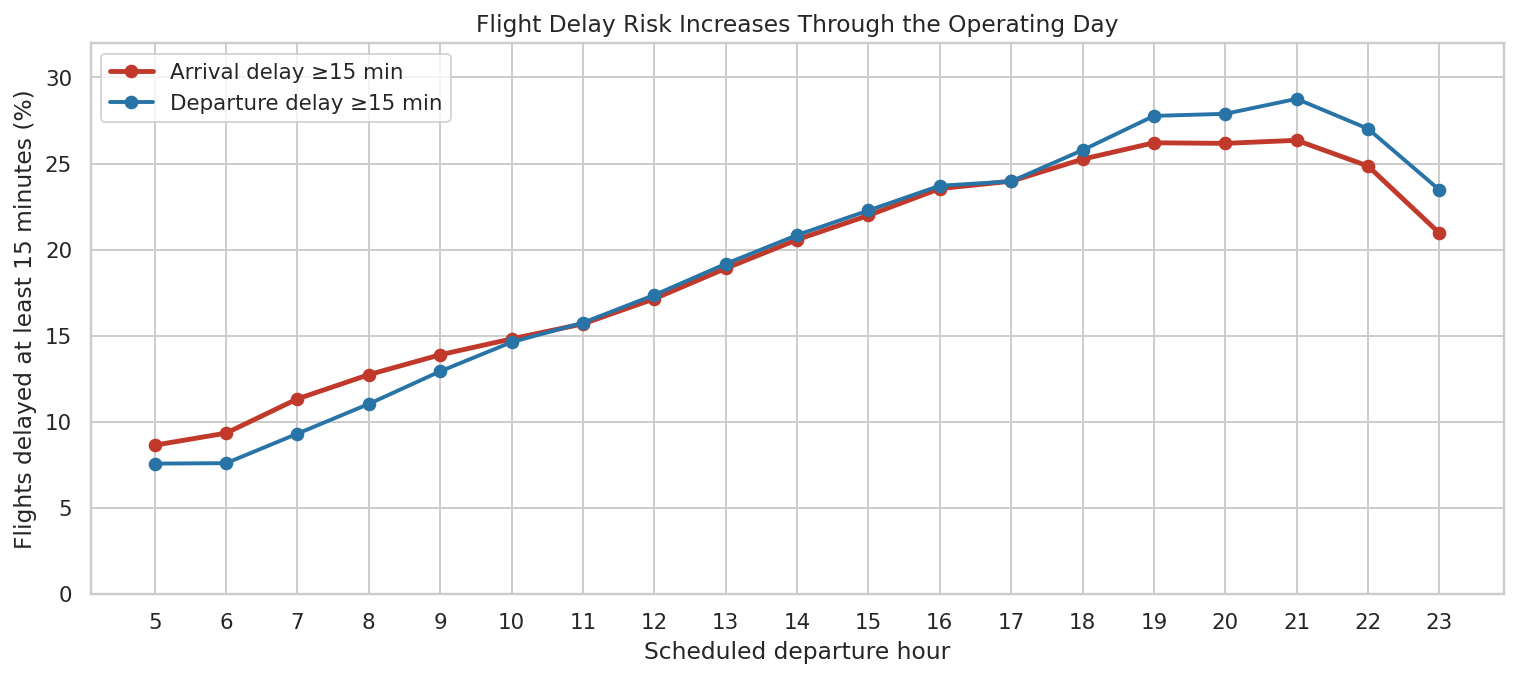

In [47]:
plot_hourly = hourly_pd[
    (hourly_pd["ScheduledDepHour"] >= 5)
    & (hourly_pd["ScheduledDepHour"] <= 23)
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    plot_hourly["ScheduledDepHour"],
    plot_hourly["arrival_delay_15m_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#C0392B",
    label="Arrival delay ≥15 min"
)

ax.plot(
    plot_hourly["ScheduledDepHour"],
    plot_hourly["departure_delay_15m_rate"] * 100,
    marker="o",
    linewidth=2.0,
    color="#2874A6",
    label="Departure delay ≥15 min"
)

ax.set(
    title="Flight Delay Risk Increases Through the Operating Day",
    xlabel="Scheduled departure hour",
    ylabel="Flights delayed at least 15 minutes (%)",
    xticks=range(5, 24),
    ylim=(0, 32)
)

ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [49]:
RESULTS_DIR = DATA_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

(
    yearly_trends
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "yearly_trends_csv"))
)

(
    monthly_seasonality
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "monthly_seasonality_csv"))
)

(
    carrier_performance
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "carrier_performance_csv"))
)

(
    origin_performance
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "origin_performance_csv"))
)

(
    hourly_performance
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(RESULTS_DIR / "hourly_performance_csv"))
)

print(f"Saved compact CSV result tables under: {RESULTS_DIR}")

Saved compact CSV result tables under: /content/drive/MyDrive/MIT805_Airline_Delays/data/results


In [50]:
from pyspark.sql import functions as F

cancellation_code_diagnostic = (
    flights
    .filter(F.col("Cancelled") == 1)
    .groupBy("Year", "Reporting_Airline", "CancellationCode")
    .count()
    .orderBy("Year", "Reporting_Airline", "CancellationCode")
)

cancellation_code_diagnostic.show(500, truncate=False)

+----+-----------------+----------------+-----+
|Year|Reporting_Airline|CancellationCode|count|
+----+-----------------+----------------+-----+
|2020|9E               |A               |132  |
|2020|9E               |B               |360  |
|2020|9E               |C               |137  |
|2020|9E               |D               |6313 |
|2020|AA               |A               |1226 |
|2020|AA               |B               |1625 |
|2020|AA               |C               |524  |
|2020|AA               |D               |30887|
|2020|AS               |A               |4976 |
|2020|AS               |B               |375  |
|2020|AS               |C               |121  |
|2020|AS               |D               |9    |
|2020|B6               |A               |1018 |
|2020|B6               |B               |132  |
|2020|B6               |C               |77   |
|2020|B6               |D               |6755 |
|2020|DL               |A               |4377 |
|2020|DL               |B               

In [51]:
raw_cancelled_sample = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .csv(str(WORKING_DIR / "*.csv"))
    .filter(F.col("Cancelled") == "1.00")
    .select(
        "Year",
        "Month",
        "Reporting_Airline",
        "FlightDate",
        "Origin",
        "Dest",
        "Cancelled",
        "CancellationCode"
    )
    .orderBy("Year", "Month", "Reporting_Airline")
    .limit(50)
)

raw_cancelled_sample.show(50, truncate=False)

+----+-----+-----------------+----------+------+----+---------+----------------+
|Year|Month|Reporting_Airline|FlightDate|Origin|Dest|Cancelled|CancellationCode|
+----+-----+-----------------+----------+------+----+---------+----------------+
|2020|1    |9E               |2020-01-17|MSP   |DAY |1.00     |C               |
|2020|1    |9E               |2020-01-11|ORD   |CVG |1.00     |A               |
|2020|1    |9E               |2020-01-17|ATL   |CID |1.00     |B               |
|2020|1    |9E               |2020-01-17|CID   |ATL |1.00     |B               |
|2020|1    |9E               |2020-01-17|DTW   |MDW |1.00     |B               |
|2020|1    |9E               |2020-01-17|MDW   |DTW |1.00     |B               |
|2020|1    |9E               |2020-01-17|MSP   |CLE |1.00     |B               |
|2020|1    |9E               |2020-01-17|DSM   |MSP |1.00     |C               |
|2020|1    |9E               |2020-01-17|MSP   |DSM |1.00     |B               |
|2020|1    |9E              

In [52]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

post2020_cancellation_causes = (
    flights
    .filter(F.col("Cancelled") == 1)
    .filter(F.col("Year") >= 2021)
    .withColumn(
        "cancellation_reason",
        F.when(F.col("CancellationCode") == "A", "Carrier")
         .when(F.col("CancellationCode") == "B", "Weather")
         .when(F.col("CancellationCode") == "C", "National Airspace System")
         .when(F.col("CancellationCode") == "D", "Security")
         .otherwise("Missing/other")
    )
    .groupBy("CancellationCode", "cancellation_reason")
    .agg(F.count("*").alias("cancelled_flights"))
    .withColumn(
        "share_of_post2020_cancellations",
        F.col("cancelled_flights")
        / F.sum("cancelled_flights").over(Window.partitionBy())
    )
    .orderBy(F.desc("cancelled_flights"))
)

post2020_cancellation_causes.show(truncate=False)

+----------------+------------------------+-----------------+-------------------------------+
|CancellationCode|cancellation_reason     |cancelled_flights|share_of_post2020_cancellations|
+----------------+------------------------+-----------------+-------------------------------+
|B               |Weather                 |248361           |0.5300018779182423             |
|A               |Carrier                 |168810           |0.36024020281517016            |
|C               |National Airspace System|49343            |0.10529786344119982            |
|D               |Security                |2090             |0.004460055825387748           |
+----------------+------------------------+-----------------+-------------------------------+



In [53]:
route_performance = (
    flights
    .groupBy("Origin", "Dest")
    .agg(
        F.count("*").alias("scheduled_flights"),
        F.sum("Cancelled").alias("cancelled_flights"),
        F.sum("Diverted").alias("diverted_flights"),
        F.avg("Cancelled").alias("cancellation_rate"),
        F.avg("Diverted").alias("diversion_rate"),
        F.avg("ArrDel15").alias("arrival_delay_15m_rate")
    )
    .filter(F.col("scheduled_flights") >= 25_000)
    .withColumn(
        "estimated_late_arrivals",
        F.round(
            F.col("scheduled_flights") * F.col("arrival_delay_15m_rate")
        ).cast("long")
    )
)

print("Highest arrival-delay rates: routes with ≥25,000 scheduled flights")
route_performance.orderBy(
    F.desc("arrival_delay_15m_rate"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

print("Highest cancellation rates: routes with ≥25,000 scheduled flights")
route_performance.orderBy(
    F.desc("cancellation_rate"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

print("Highest estimated late-arrival volume: routes with ≥25,000 scheduled flights")
route_performance.orderBy(
    F.desc("estimated_late_arrivals"),
    F.desc("scheduled_flights")
).show(20, truncate=False)

Highest arrival-delay rates: routes with ≥25,000 scheduled flights
+------+----+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+-----------------------+
|Origin|Dest|scheduled_flights|cancelled_flights|diverted_flights|cancellation_rate   |diversion_rate       |arrival_delay_15m_rate|estimated_late_arrivals|
+------+----+-----------------+-----------------+----------------+--------------------+---------------------+----------------------+-----------------------+
|MIA   |JFK |25514            |653              |55              |0.0255937916438034  |0.0021556792349298423|0.27529629928243166   |7024                   |
|DFW   |LAS |26617            |643              |31              |0.0241574933313296  |0.0011646691963782545|0.2726361638977759    |7257                   |
|LAS   |SAN |26486            |678              |26              |0.02559842935890659 |9.816506833798988E-4 |0.2706927313629664    |7170            

In [55]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

FIGURES_DIR = DATA_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"

yearly_pd = yearly_trends.toPandas()
monthly_pd = monthly_seasonality.toPandas()
hourly_pd = hourly_performance.toPandas()
routes_pd = route_performance.toPandas()

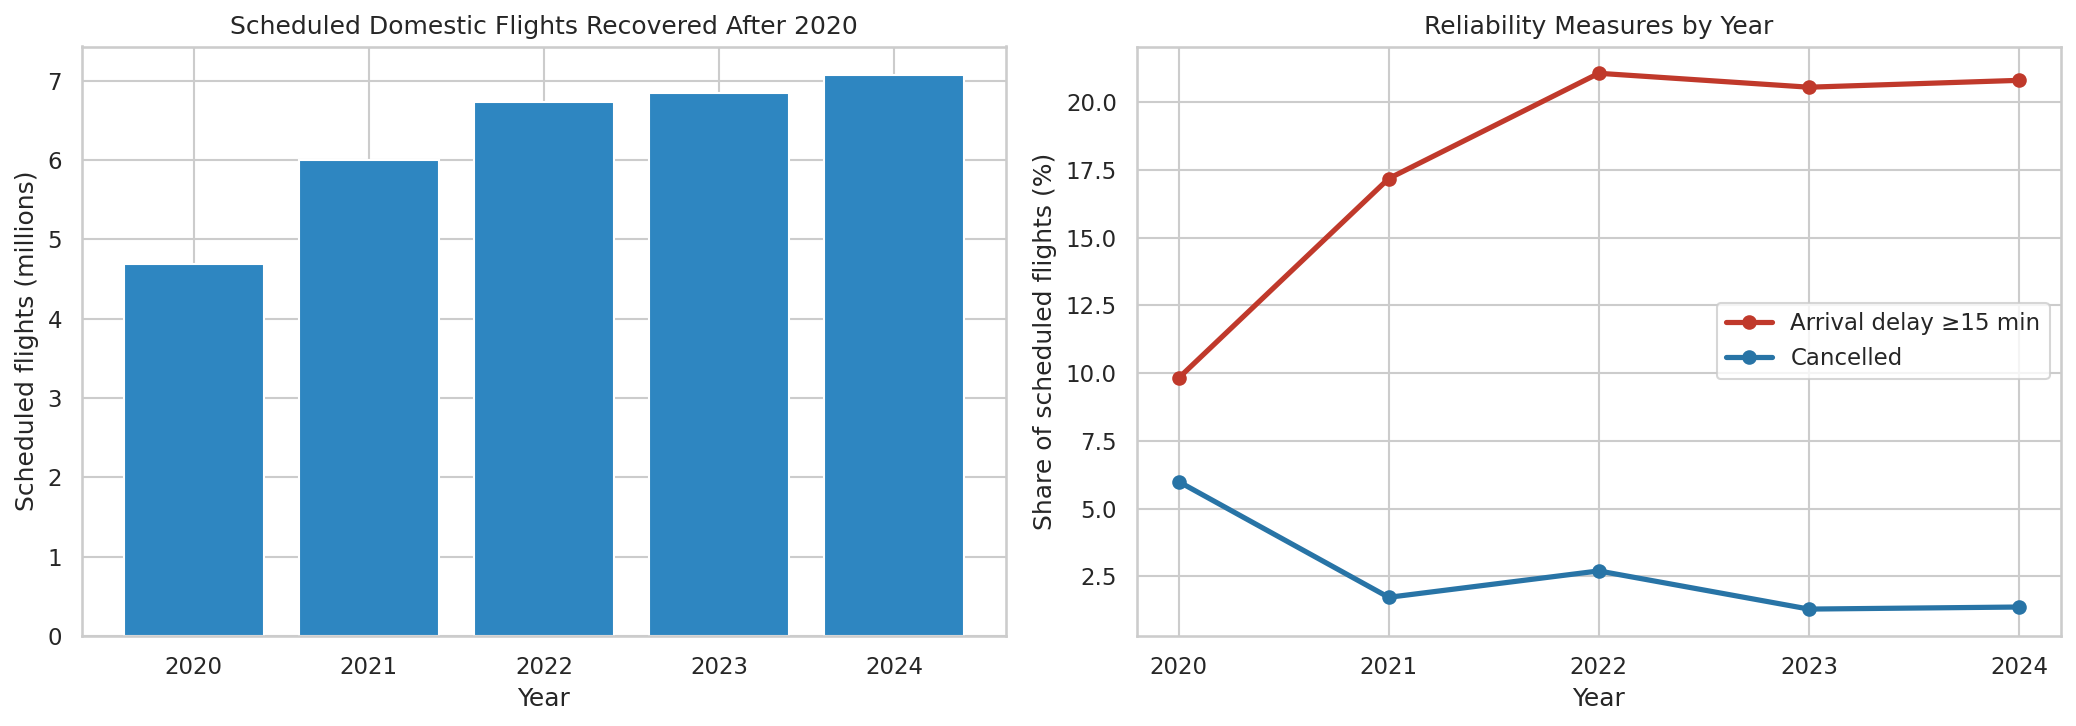

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    yearly_pd["Year"].astype(str),
    yearly_pd["scheduled_flights"] / 1_000_000,
    color="#2E86C1"
)
axes[0].set(
    title="Scheduled Domestic Flights Recovered After 2020",
    xlabel="Year",
    ylabel="Scheduled flights (millions)"
)

axes[1].plot(
    yearly_pd["Year"],
    yearly_pd["arrival_delay_15m_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#C0392B",
    label="Arrival delay ≥15 min"
)
axes[1].plot(
    yearly_pd["Year"],
    yearly_pd["cancellation_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#2874A6",
    label="Cancelled"
)
axes[1].set(
    title="Reliability Measures by Year",
    xlabel="Year",
    ylabel="Share of scheduled flights (%)",
    xticks=yearly_pd["Year"]
)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_yearly_volume_and_reliability.png", bbox_inches="tight")
plt.show()

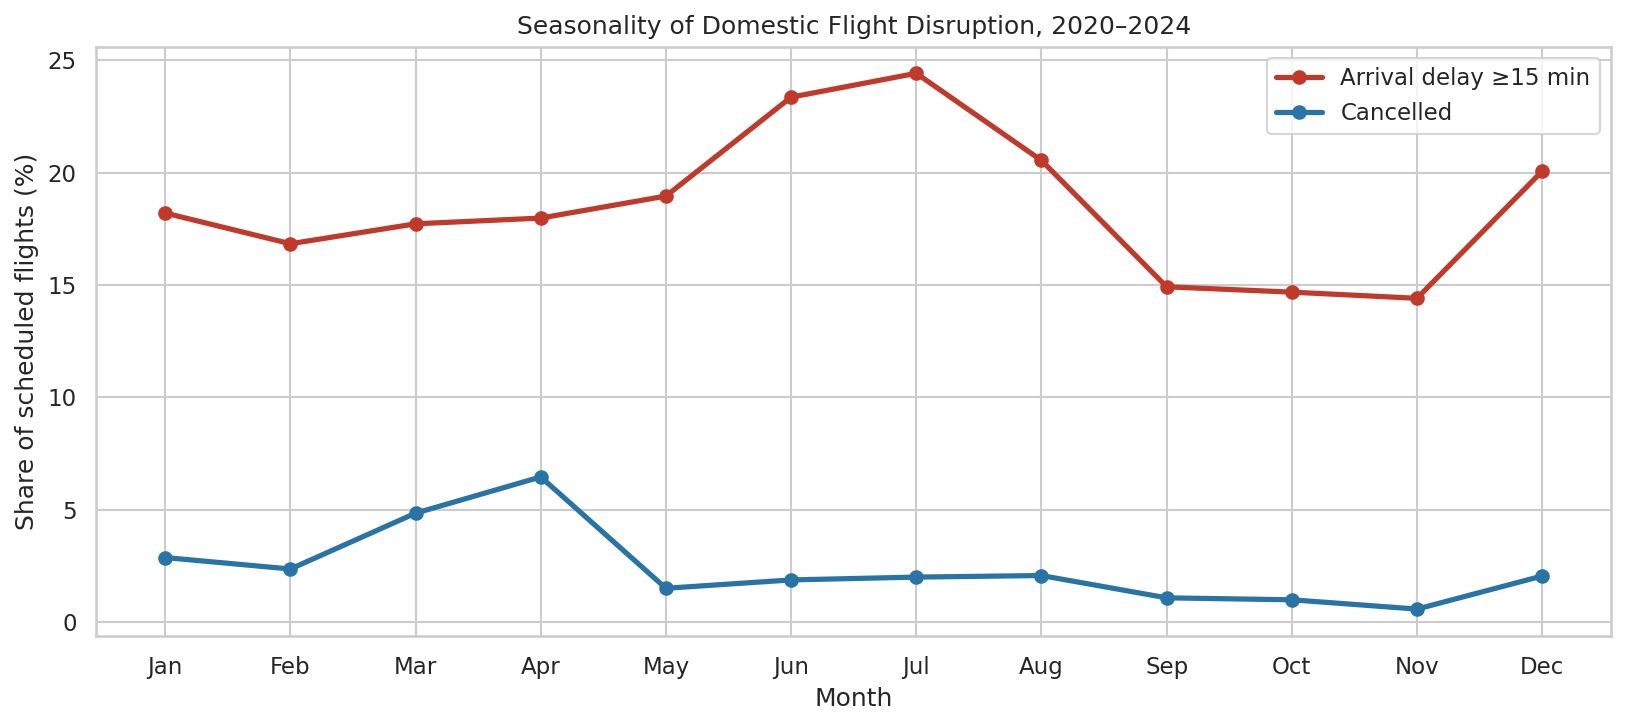

In [57]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    monthly_pd["Month"],
    monthly_pd["arrival_delay_15m_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#C0392B",
    label="Arrival delay ≥15 min"
)

ax.plot(
    monthly_pd["Month"],
    monthly_pd["cancellation_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#2874A6",
    label="Cancelled"
)

ax.set(
    title="Seasonality of Domestic Flight Disruption, 2020–2024",
    xlabel="Month",
    ylabel="Share of scheduled flights (%)",
    xticks=range(1, 13)
)

ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_monthly_seasonality.png", bbox_inches="tight")
plt.show()

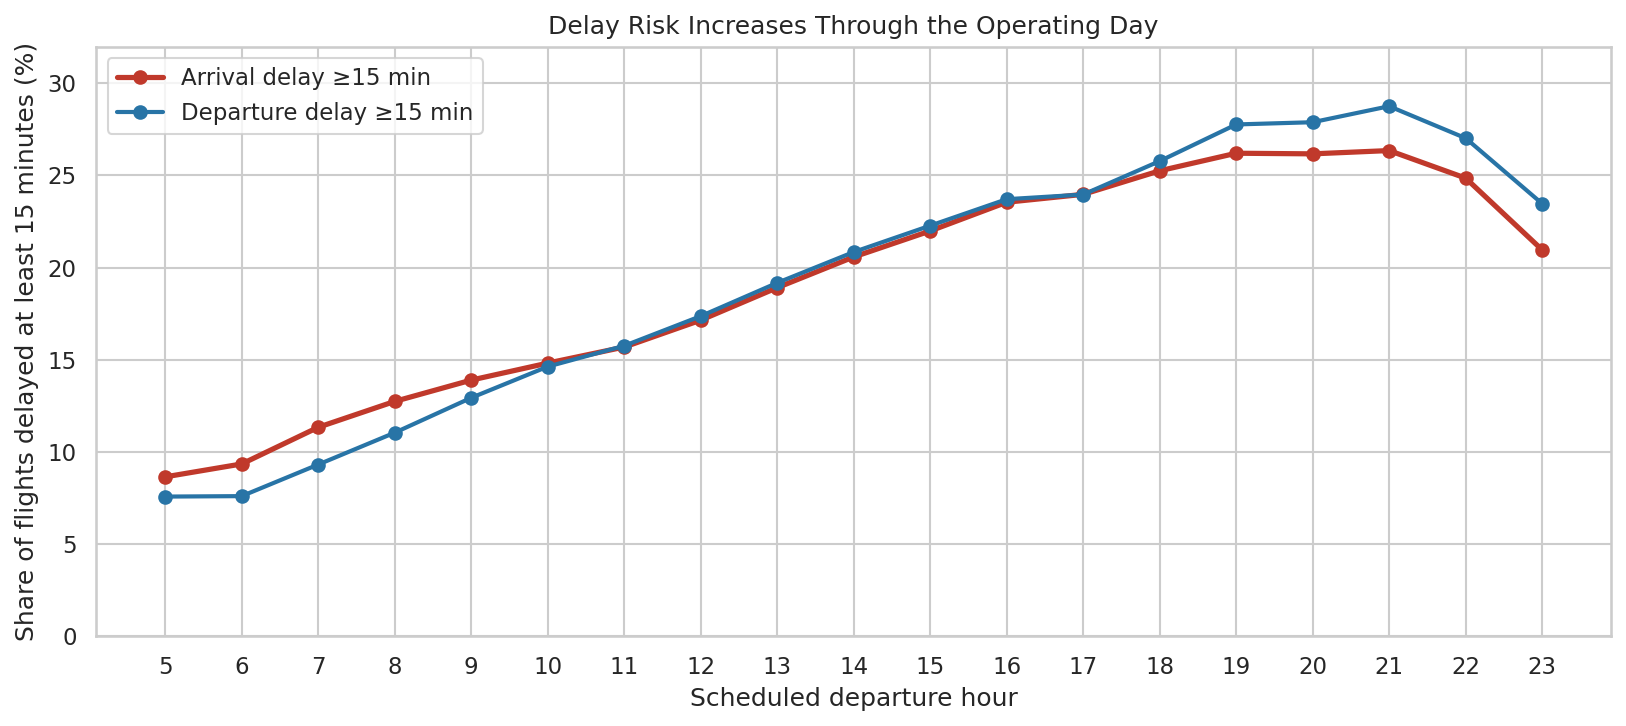

In [58]:
plot_hourly = hourly_pd[
    hourly_pd["ScheduledDepHour"].between(5, 23)
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    plot_hourly["ScheduledDepHour"],
    plot_hourly["arrival_delay_15m_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#C0392B",
    label="Arrival delay ≥15 min"
)

ax.plot(
    plot_hourly["ScheduledDepHour"],
    plot_hourly["departure_delay_15m_rate"] * 100,
    marker="o",
    linewidth=2.0,
    color="#2874A6",
    label="Departure delay ≥15 min"
)

ax.set(
    title="Delay Risk Increases Through the Operating Day",
    xlabel="Scheduled departure hour",
    ylabel="Share of flights delayed at least 15 minutes (%)",
    xticks=range(5, 24),
    ylim=(0, 32)
)

ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_hourly_delay_risk.png", bbox_inches="tight")
plt.show()

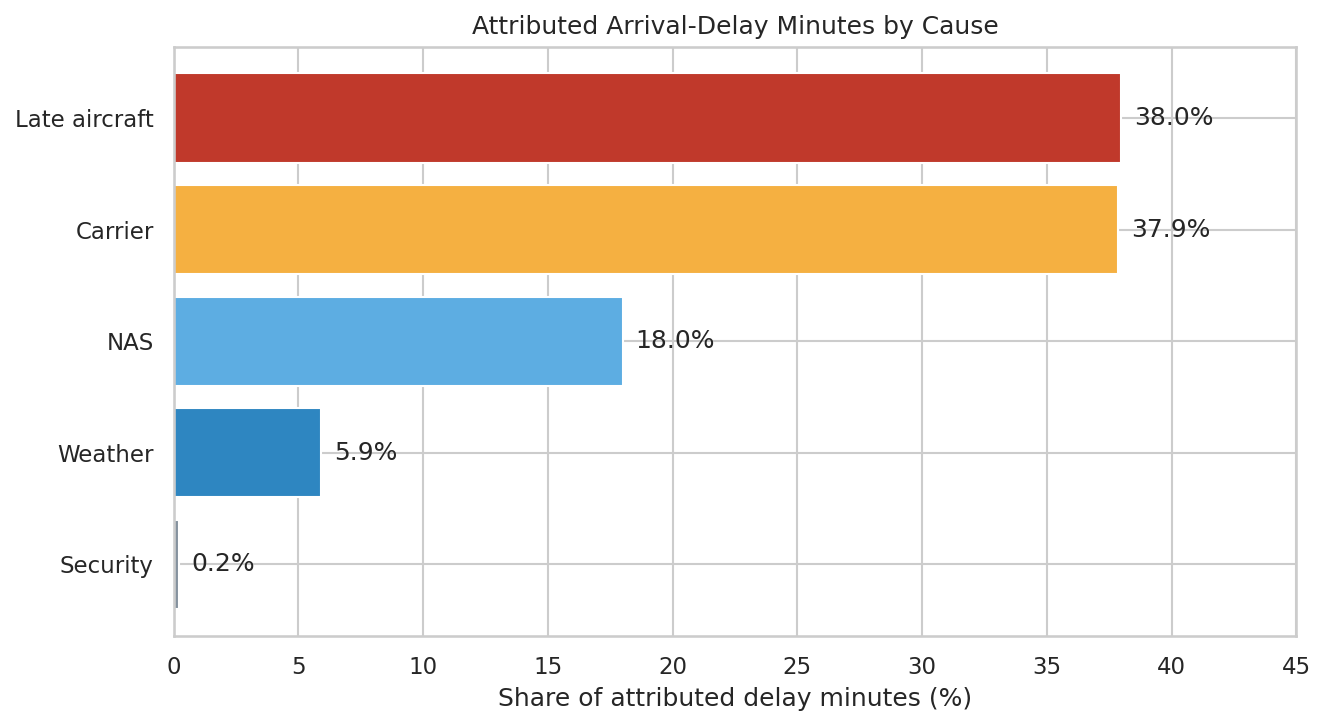

In [59]:
cause_pd = pd.DataFrame({
    "Cause": [
        "Late aircraft",
        "Carrier",
        "NAS",
        "Weather",
        "Security"
    ],
    "Share": [
        0.3798764891249255,
        0.37857170748775204,
        0.1801105490951,
        0.05918037439145358,
        0.002260879900768866
    ]
}).sort_values("Share", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    cause_pd["Cause"],
    cause_pd["Share"] * 100,
    color=["#85929E", "#2E86C1", "#5DADE2", "#F5B041", "#C0392B"]
)

ax.set(
    title="Attributed Arrival-Delay Minutes by Cause",
    xlabel="Share of attributed delay minutes (%)",
    ylabel=""
)

for index, value in enumerate(cause_pd["Share"] * 100):
    ax.text(value + 0.5, index, f"{value:.1f}%", va="center")

ax.set_xlim(0, 45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_delay_cause_mix.png", bbox_inches="tight")
plt.show()

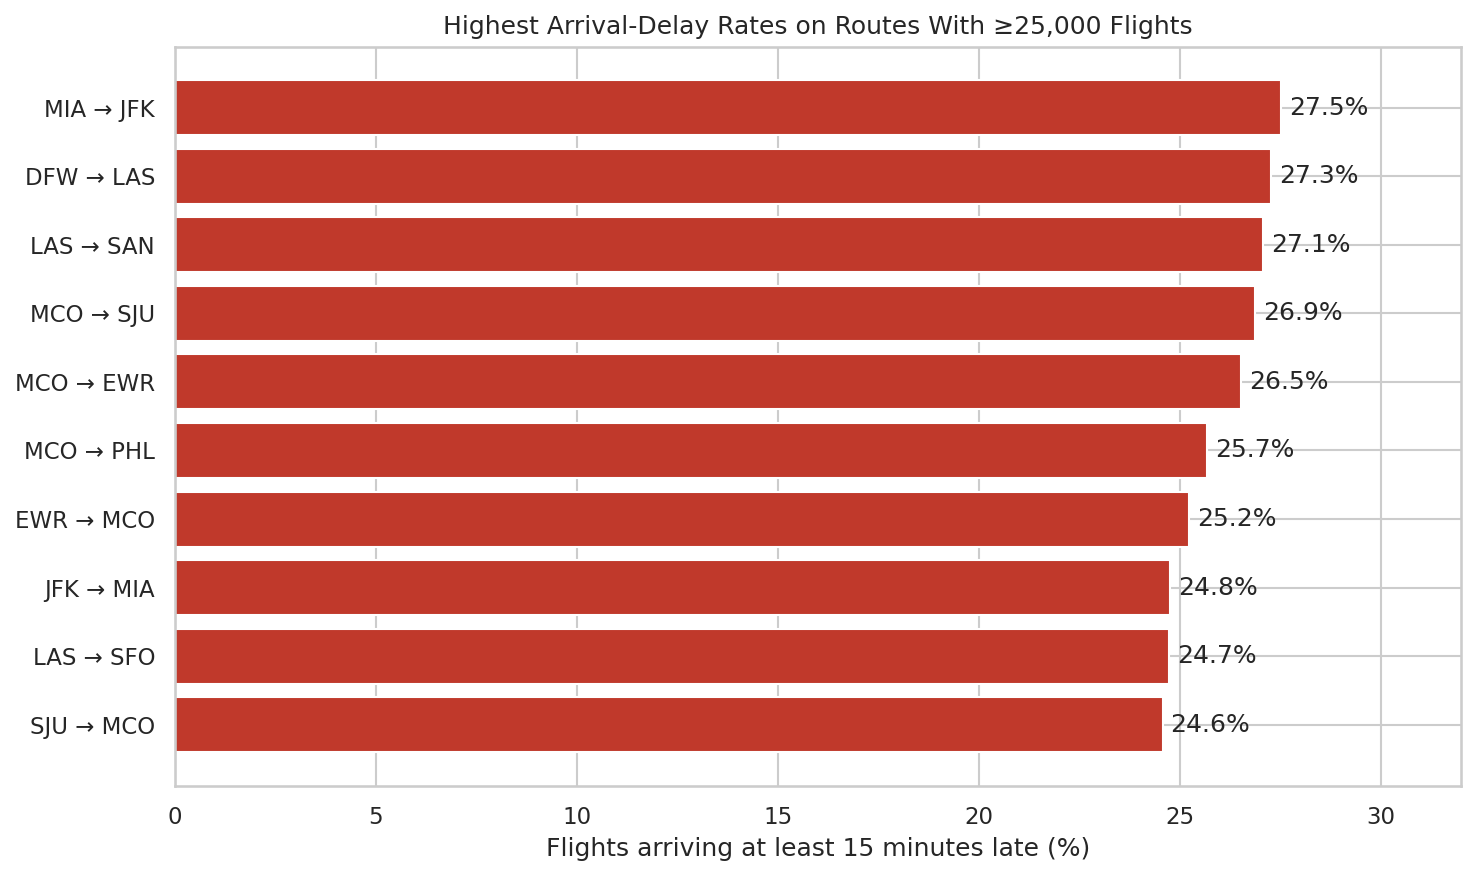

In [60]:
top_delay_routes = (
    routes_pd
    .sort_values(
        ["arrival_delay_15m_rate", "scheduled_flights"],
        ascending=[False, False]
    )
    .head(10)
    .copy()
)

top_delay_routes["route"] = (
    top_delay_routes["Origin"] + " → " + top_delay_routes["Dest"]
)

top_delay_routes = top_delay_routes.sort_values(
    "arrival_delay_15m_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_delay_routes["route"],
    top_delay_routes["arrival_delay_15m_rate"] * 100,
    color="#C0392B"
)

ax.set(
    title="Highest Arrival-Delay Rates on Routes With ≥25,000 Flights",
    xlabel="Flights arriving at least 15 minutes late (%)",
    ylabel=""
)

for index, value in enumerate(top_delay_routes["arrival_delay_15m_rate"] * 100):
    ax.text(value + 0.2, index, f"{value:.1f}%", va="center")

ax.set_xlim(0, 32)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_high_risk_routes.png", bbox_inches="tight")
plt.show()